# ⚖️ Responsible AI (الذكاء الاصطناعي المسؤول) & Ethics
**Day 4 — Modern ML & the Bigger Picture**

---

You can now build Machine Learning (التعلم الآلي) models. That's powerful — and with power comes responsibility.

This notebook examines the real-world consequences of ML systems and the principles that guide responsible development. There are no right or wrong answers here — only tradeoffs to think carefully about.

Topics:
1. **Bias in data and models** — where it comes from, how to detect it
2. **Fairness** — what it means, why it's hard to define
3. **Transparency and explainability** — can you understand *why* a model made a decision?
4. **Case studies** — real-world ML failures and what they taught us

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings; warnings.filterwarnings("ignore")
np.random.seed(42)
print("Ready ✓")

Ready ✓


## 1. Where Does Bias Come From?

Bias in ML doesn't usually come from bad intentions — it comes from **data that reflects existing inequalities**, combined with models that learn and amplify those patterns.

**Three common sources:**

1. **Historical bias**: the data reflects past discrimination (e.g., hiring data where qualified people were historically passed over)
2. **Representation bias**: some groups are underrepresented in the training data (e.g., medical datasets with mostly male patients)
3. **Measurement bias**: the proxy variable you're measuring doesn't equally represent the concept across groups (e.g., using credit score as a proxy for creditworthiness when access to credit is unequal)

In [2]:
# Simulate a biased hiring dataset
# A fictional tech company's historical hiring data
# Problem: the company historically hired fewer women, creating a biased training set

np.random.seed(7)
n = 2000

# Applicant features
experience = np.random.randint(0, 15, n)
education_score = np.random.uniform(60, 100, n).round(1)
technical_test  = np.random.uniform(50, 100, n).round(1)
gender = np.random.choice([0, 1], n, p=[0.55, 0.45])  # 0=male, 1=female (in this dataset)

# Historical hiring: BIASED — women with same qualifications were hired less often
# This reflects the company's PAST behavior, not candidates' actual merit
base_prob = (0.02 * experience + 0.005 * education_score + 0.008 * technical_test - 0.85)
bias_factor = np.where(gender == 1, -0.25, 0)  # women penalized 25% historically
hire_prob = (base_prob + bias_factor).clip(0.05, 0.95)
hired = (np.random.random(n) < hire_prob).astype(int)

df_hire = pd.DataFrame({
    "experience": experience,
    "education_score": education_score,
    "technical_test": technical_test,
    "gender": gender,
    "hired": hired
})

# Show the disparate outcomes
hire_rates = df_hire.groupby("gender")["hired"].agg(["mean", "count"])
hire_rates.index = ["Male (0)", "Female (1)"]
hire_rates.columns = ["Hire Rate", "Count"]
hire_rates["Hire Rate"] = hire_rates["Hire Rate"].map("{:.1%}".format)

print("Historical hiring rates:")
print(hire_rates)
print()
print("Qualifications are statistically IDENTICAL between groups:")
for col in ["experience", "education_score", "technical_test"]:
    m = df_hire[df_hire.gender==0][col].mean()
    f = df_hire[df_hire.gender==1][col].mean()
    print(f"  {col}: Male={m:.1f}, Female={f:.1f}")

Historical hiring rates:
           Hire Rate  Count
Male (0)       29.8%   1133
Female (1)      7.5%    867

Qualifications are statistically IDENTICAL between groups:
  experience: Male=7.1, Female=6.8
  education_score: Male=80.1, Female=80.5
  technical_test: Male=75.7, Female=74.8


In [3]:
# Train a model on this biased historical data
features = ["experience", "education_score", "technical_test"]
X = df_hire[features].values
y = df_hire["hired"].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
gender_te = df_hire["gender"].values[y_te.shape[0]*-1 if len(X_te) < len(df_hire) else 0:]
gender_te = df_hire.iloc[len(df_hire)-len(X_te):]["gender"].values

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s  = scaler.transform(X_te)

model_biased = LogisticRegression(random_state=42)
model_biased.fit(X_tr_s, y_tr)
y_pred_biased = model_biased.predict(X_te_s)

# Measure bias: different hire rates by gender
# Note: gender was NOT used as a feature — the model learned the bias from correlated features
from sklearn.metrics import accuracy_score

print("Model trained WITHOUT gender as a feature:")
print(f"Overall accuracy: {accuracy_score(y_te, y_pred_biased):.1%}")
print()
print("BUT — predicted hire rates by gender:")
for g_label, g_val in [("Male", 0), ("Female", 1)]:
    mask = gender_te == g_val
    if mask.sum() > 0:
        rate = y_pred_biased[mask].mean()
        print(f"  {g_label}: {rate:.1%} predicted as hired")

print()
print("CRITICAL INSIGHT: Removing gender from the features does NOT remove bias.")
print("The model can infer gender from correlated features (test scores, education patterns)")
print("and perpetuate historical discrimination.")

Model trained WITHOUT gender as a feature:
Overall accuracy: 80.5%

BUT — predicted hire rates by gender:
  Male: 4.0% predicted as hired
  Female: 0.6% predicted as hired

CRITICAL INSIGHT: Removing gender from the features does NOT remove bias.
The model can infer gender from correlated features (test scores, education patterns)
and perpetuate historical discrimination.


## 2. What is Fairness? (It's Harder Than It Sounds)

There are multiple mathematically valid definitions of fairness — and they often **cannot all be satisfied simultaneously**. This is a fundamental mathematical result, not a flaw.

**Common fairness metrics:**

| Metric | Definition | Example |
|---|---|---|
| **Demographic parity** | Equal positive prediction rates across groups | Hire the same % of men and women |
| **Equal opportunity** | Equal true positive rates across groups | Detect disease at same rate in all groups |
| **Calibration** | Predicted probability = actual probability for all groups | A 70% prediction = 70% likely outcome for everyone |

Depending on your application, different fairness criteria may be appropriate — and they can conflict with each other.

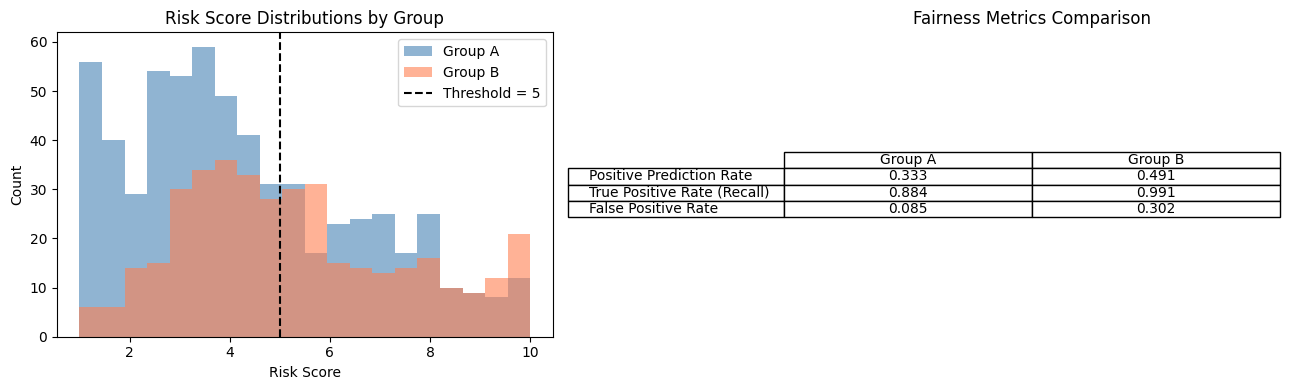

Note: equal actual recidivism rates (30%), but:
  Group B gets higher scores → higher prediction rates
  This is a real documented pattern in criminal justice algorithms


In [4]:
# Show the tradeoff: improving one fairness metric can worsen another
# Simulate the classic criminal justice algorithm COMPAS-style scenario

np.random.seed(42)
n_cj = 1000
# Two groups with same actual recidivism rates (30%)
group = np.random.choice([0, 1], n_cj, p=[0.6, 0.4])
actual_risk = (np.random.random(n_cj) < 0.30).astype(int)

# Algorithm gives scores 1-10; slight systematic difference due to socioeconomic correlates
base_score = 3 + 4*actual_risk + np.random.normal(0, 1.5, n_cj)
group_effect = np.where(group == 1, 1.2, 0)  # group 1 gets systematically higher scores
risk_score = (base_score + group_effect).clip(1, 10)

# Threshold: predict "high risk" if score > 5
high_risk_pred = (risk_score > 5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Risk score distributions by group
for g, label, color in [(0, "Group A", "steelblue"), (1, "Group B", "coral")]:
    mask = group == g
    axes[0].hist(risk_score[mask], bins=20, alpha=0.6, color=color, label=label)
axes[0].axvline(5, color="black", linestyle="--", label="Threshold = 5")
axes[0].set_xlabel("Risk Score"); axes[0].set_ylabel("Count")
axes[0].set_title("Risk Score Distributions by Group", fontsize=12)
axes[0].legend()

# Fairness metrics comparison
metrics = {}
for g, label in [(0, "Group A"), (1, "Group B")]:
    mask = group == g
    actual_g = actual_risk[mask]
    pred_g   = high_risk_pred[mask]
    tp = ((actual_g == 1) & (pred_g == 1)).sum()
    fp = ((actual_g == 0) & (pred_g == 1)).sum()
    tn = ((actual_g == 0) & (pred_g == 0)).sum()
    fn = ((actual_g == 1) & (pred_g == 0)).sum()
    metrics[label] = {
        "Positive Prediction Rate": (tp + fp) / mask.sum(),
        "True Positive Rate (Recall)": tp / (tp + fn) if (tp + fn) > 0 else 0,
        "False Positive Rate": fp / (fp + tn) if (fp + tn) > 0 else 0,
    }

metric_df = pd.DataFrame(metrics).round(3)
axes[1].table(cellText=metric_df.values, rowLabels=metric_df.index, colLabels=metric_df.columns,
              loc="center", cellLoc="center")
axes[1].axis("off")
axes[1].set_title("Fairness Metrics Comparison", fontsize=12)
plt.tight_layout(); plt.show()

print("Note: equal actual recidivism rates (30%), but:")
print("  Group B gets higher scores → higher prediction rates")
print("  This is a real documented pattern in criminal justice algorithms")

## 3. Case Studies

### Case Study 1: Amazon's Hiring Algorithm (2018)

Amazon built an AI to screen resumes. After training on 10 years of hiring data (predominantly male hires), the model **penalized resumes with the word "women's"** (e.g., "women's chess club") and downgraded graduates of all-women's colleges.

**What went wrong?** The model learned from biased historical data.  
**What happened?** Amazon scrapped the project.  
**Lesson:** Historical data encodes historical bias.

### Case Study 2: Pulse Oximeters and Race (2020)

A study found that pulse oximeters (medical devices measuring blood oxygen) were significantly **less accurate for patients with darker skin tones**. Many clinical algorithms that used oximeter readings made worse decisions for Black patients.

**What went wrong?** The devices were designed and tested primarily on lighter-skinned patients.  
**Lesson:** Representation in training data matters for physical devices too, not just software.

### Case Study 3: Predictive Policing

Several cities deployed ML systems to predict where crimes would occur and allocate police resources. These systems trained on historical arrest data — which reflected patterns of *over-policing* in certain neighborhoods — creating a self-reinforcing loop: more policing → more arrests → more predictions → more policing.

**What went wrong?** The system optimized for arrests (proxy), not crime (actual goal), and feedback loops amplified existing disparities.  
**Lesson:** Carefully audit what your model is actually measuring and what feedback loops it creates.

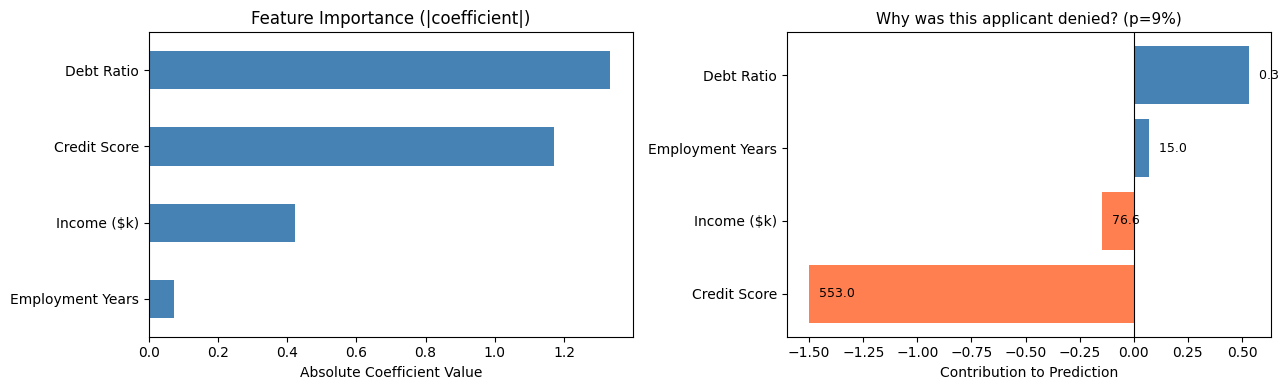

Explainability matters: loan applicants in many countries have a legal right
to understand why they were denied credit.


In [5]:
# Explainability: LIME-style feature importance demo
# When a model makes a decision affecting someone's life, they deserve an explanation

from sklearn.inspection import permutation_importance

np.random.seed(42)
n_loan = 800
credit_score = np.random.randint(500, 850, n_loan)
income_k = np.random.uniform(25, 150, n_loan).round(1)
debt_ratio = np.random.uniform(0.1, 0.6, n_loan).round(2)
employment_years = np.random.randint(0, 20, n_loan)

approved = ((credit_score > 650) & (income_k > 40) & (debt_ratio < 0.4)).astype(int)
approved = np.where(np.random.random(n_loan) < 0.05, 1-approved, approved)  # small noise

X_loan = np.column_stack([credit_score, income_k, debt_ratio, employment_years])
y_loan = approved
feature_names_loan = ["Credit Score", "Income ($k)", "Debt Ratio", "Employment Years"]

X_lt, X_le, y_lt, y_le = train_test_split(X_loan, y_loan, test_size=0.2, random_state=42)
scaler_l = StandardScaler()
X_lt_s = scaler_l.fit_transform(X_lt)
X_le_s = scaler_l.transform(X_le)

model_loan = LogisticRegression(random_state=42)
model_loan.fit(X_lt_s, y_lt)

# Feature importance via coefficients
coefs = pd.Series(np.abs(model_loan.coef_[0]), index=feature_names_loan).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

coefs.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Feature Importance (|coefficient|)", fontsize=12)
axes[0].set_xlabel("Absolute Coefficient Value")

# Show a specific prediction with explanation
idx = 15  # a specific applicant
x_single = X_le[idx]
x_single_s = X_le_s[idx].reshape(1, -1)
pred = model_loan.predict(x_single_s)[0]
proba = model_loan.predict_proba(x_single_s)[0, 1]

contributions = model_loan.coef_[0] * x_single_s[0]
contrib_df = pd.DataFrame({
    "Feature": feature_names_loan,
    "Value": x_single,
    "Contribution": contributions
}).sort_values("Contribution")

colors_c = ["coral" if c < 0 else "steelblue" for c in contrib_df["Contribution"]]
axes[1].barh(contrib_df["Feature"], contrib_df["Contribution"], color=colors_c)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title(f"Why was this applicant {'approved' if pred else 'denied'}? (p={proba:.0%})", fontsize=11)
axes[1].set_xlabel("Contribution to Prediction")
for i, (_, row) in enumerate(contrib_df.iterrows()):
    axes[1].text(row["Contribution"] + 0.01, i, f"  {row['Value']:.1f}", va="center", fontsize=9)

plt.tight_layout(); plt.show()
print("Explainability matters: loan applicants in many countries have a legal right")
print("to understand why they were denied credit.")

## 4. Principles for Responsible ML

The EU AI Act, NIST AI Risk Management Framework, and Anthropic's research all point to similar principles:

**Before building:**
- Who will be affected? Which groups could be harmed by errors?
- What's the cost of a false positive vs. false negative? Are they equal across groups?
- Is there a human in the loop for high-stakes decisions?

**During development:**
- Evaluate performance separately for each demographic group
- Check for proxy variables that encode protected attributes
- Document your data sources, preprocessing decisions, and known limitations

**After deployment:**
- Monitor for distribution shift (data changes over time)
- Create feedback mechanisms for people harmed by errors
- Be willing to pull the system if harm is discovered

---

## Discussion Questions

Take 5 minutes to discuss with a partner:

In [6]:
discussion_questions = [
    "1. A hospital wants to use ML to predict which patients are at risk of readmission within 30 days. "
    "   The model performs 15% better for patients with complete electronic health records. "
    "   Patients from lower-income neighborhoods often have less complete records. "
    "   Should the hospital deploy this model? What safeguards would you recommend?",

    "2. A university uses an ML model to predict which applicants will succeed academically. "
    "   The model is 78% accurate overall. "
    "   But its accuracy is only 62% for first-generation college students. "
    "   What are the fairness implications? Is 78% overall accuracy a meaningful number?",

    "3. A self-driving car must decide: swerve left (hitting a wall, likely injuring the passenger) "
    "   or swerve right (hitting a pedestrian). "
    "   Should ML be used to make this decision? Who decides what the model optimizes for?",
]

for q in discussion_questions:
    print(q)
    print()

1. A hospital wants to use ML to predict which patients are at risk of readmission within 30 days.    The model performs 15% better for patients with complete electronic health records.    Patients from lower-income neighborhoods often have less complete records.    Should the hospital deploy this model? What safeguards would you recommend?

2. A university uses an ML model to predict which applicants will succeed academically.    The model is 78% accurate overall.    But its accuracy is only 62% for first-generation college students.    What are the fairness implications? Is 78% overall accuracy a meaningful number?

3. A self-driving car must decide: swerve left (hitting a wall, likely injuring the passenger)    or swerve right (hitting a pedestrian).    Should ML be used to make this decision? Who decides what the model optimizes for?



---

## Course Wrap-Up: The Through-Line

Across four days, you followed a single idea from its simplest form to its most powerful application:

**Day 1** — A line through data points. Four numbers learned from 20 houses.  
**Day 2** — Data is the foundation. Garbage in, garbage out.  
**Day 3** — Multiple algorithms. Same idea, different shapes of boundaries.  
**Day 4** — Scale the idea to billions of parameters. Watch intelligence emerge.

And now: recognize that the models you build will affect real people's lives. The choices you make — what data to collect, how to define success, who to include in testing — are ethical choices, not just technical ones.

The most dangerous engineer isn't one who writes bad code. It's one who writes technically correct code without thinking about who it affects.

**You now have the foundation to go further.** Some places to explore next:
- Deep Learning (التعلم العميق): PyTorch, fast.ai, Hugging Face
- ML fairness: IBM AI Fairness 360, Google's What-If Tool
- Ethics: "Weapons of Math Destruction" (book), Timnit Gebru's research
- Practitioner community: Kaggle, ML papers on arxiv.org, local ML meetups